In [1]:
!pip install -q pdfplumber python-docx python-pptx odfpy openpyxl pandas langchain-text-splitters

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 81.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 112.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 95.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
gra

In [2]:
import os

DATA_DIR = "/kaggle/input/datasets/ripperdzz/document-docmind"

files = []
for root, _, filenames in os.walk(DATA_DIR):
    for f in filenames:
        files.append(os.path.join(root, f))

for f in files:
    print(f)

/kaggle/input/datasets/ripperdzz/document-docmind/L1_MI_TD1_analyse2_21.pdf
/kaggle/input/datasets/ripperdzz/document-docmind/Notes Algorithmique 1.pdf
/kaggle/input/datasets/ripperdzz/document-docmind/Machine Learning.pptx
/kaggle/input/datasets/ripperdzz/document-docmind/controle-systeme-2020.docx
/kaggle/input/datasets/ripperdzz/document-docmind/L1_MI_TD0_analyse2_21.pdf
/kaggle/input/datasets/ripperdzz/document-docmind/Ch2_Algbre1-2021-2022.pdf
/kaggle/input/datasets/ripperdzz/document-docmind/bilan_annuel_L2-1.xls
/kaggle/input/datasets/ripperdzz/document-docmind/Ethical AI.pptx
/kaggle/input/datasets/ripperdzz/document-docmind/TD N2-lmd S5-2023-2024.docx
/kaggle/input/datasets/ripperdzz/document-docmind/Academic writing.pptx
/kaggle/input/datasets/ripperdzz/document-docmind/NoteEvaluationCC_CM_1331577.xlsx (1).xlsx
/kaggle/input/datasets/ripperdzz/document-docmind/controle-systeme-1-2019.docx
/kaggle/input/datasets/ripperdzz/document-docmind/controle-tp-finale-2016.docx
/kaggle/i

In [3]:
!pip install -q pymupdf

import fitz  # PyMuPDF
from docx import Document as DocxDocument
from pptx import Presentation
import pandas as pd
from odf.opendocument import load as load_ods
from odf.table import Table, TableRow, TableCell
from odf.text import P

def extract_pdf(path):
    chunks = []
    doc = fitz.open(path)
    for i, page in enumerate(doc):
        text = page.get_text()
        if text.strip():
            chunks.append({"text": text, "page": i+1, "type": "text"})
        tables = page.find_tables()
        for table in tables:
            rows = table.extract()
            table_text = "\n".join([" | ".join([str(c) if c else "" for c in row]) for row in rows])
            chunks.append({"text": table_text, "page": i+1, "type": "table"})
    return chunks

def extract_docx(path):
    doc = DocxDocument(path)
    chunks = []
    para_buffer = []
    for para in doc.paragraphs:
        if para.text.strip():
            para_buffer.append(para.text)
    if para_buffer:
        chunks.append({"text": "\n".join(para_buffer), "type": "text"})
    for t_idx, table in enumerate(doc.tables):
        rows = []
        for row in table.rows:
            rows.append(" | ".join(cell.text for cell in row.cells))
        chunks.append({"text": "\n".join(rows), "type": "table"})
    return chunks

def extract_pptx(path):
    prs = Presentation(path)
    chunks = []
    for i, slide in enumerate(prs.slides):
        slide_text = []
        for shape in slide.shapes:
            if shape.has_text_frame:
                for para in shape.text_frame.paragraphs:
                    line = "".join(run.text for run in para.runs)
                    if line.strip():
                        slide_text.append(line)
        if slide_text:
            chunks.append({"text": "\n".join(slide_text), "page": i+1, "type": "slide"})
    return chunks

def extract_xlsx(path):
    chunks = []
    xls = pd.ExcelFile(path)
    for sheet_name in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)
        df = df.dropna(how="all").dropna(axis=1, how="all")
        df = df.fillna("")  # replace NaN with empty string
        text = df.to_string(index=False, header=False)
        chunks.append({"text": text, "sheet": sheet_name, "type": "table"})
    return chunks

def extract_ods(path):
    doc = load_ods(path)
    chunks = []
    for table in doc.getElementsByType(Table):
        rows_text = []
        for row in table.getElementsByType(TableRow):
            cells = row.getElementsByType(TableCell)
            row_vals = []
            for cell in cells:
                ps = cell.getElementsByType(P)
                row_vals.append(" ".join(str(p) for p in ps))
            rows_text.append(" | ".join(row_vals))
        chunks.append({"text": "\n".join(rows_text), "type": "table"})
    return chunks


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 72.2 MB/s eta 0:00:00:00:0100:01


In [4]:
EXTRACTORS = {
    ".pdf": extract_pdf,
    ".docx": extract_docx,
    ".pptx": extract_pptx,
    ".xlsx": extract_xlsx,
    ".xls": extract_xlsx,
    ".ods": extract_ods,
}

def normalize_file(path):
    ext = os.path.splitext(path)[1].lower()
    extractor = EXTRACTORS.get(ext)
    if extractor is None:
        return None  # .doc and anything unsupported falls here
    try:
        raw_chunks = extractor(path)
    except Exception as e:
        print(f"FAILED: {path} -> {e}")
        return None

    normalized = []
    for c in raw_chunks:
        normalized.append({
            "doc_id": os.path.basename(path),
            "source_path": path,
            "file_type": ext,
            "text": c["text"],
            "chunk_type": c.get("type", "text"),
            "page_or_sheet": c.get("page") or c.get("sheet"),
        })
    return normalized

all_chunks = []
skipped = []
for f in files:
    result = normalize_file(f)
    if result is None:
        skipped.append(f)
    else:
        all_chunks.extend(result)

print(f"Normalized {len(all_chunks)} chunks from {len(files)-len(skipped)} files")
print(f"Skipped: {skipped}")

Consider using the pymupdf_layout package for a greatly improved page layout analysis.
FAILED: /kaggle/input/datasets/ripperdzz/document-docmind/TD N2-lmd S5-2023-2024.docx -> Package not found at '/kaggle/input/datasets/ripperdzz/document-docmind/TD N2-lmd S5-2023-2024.docx'
Normalized 240 chunks from 26 files
Skipped: ['/kaggle/input/datasets/ripperdzz/document-docmind/TD N2-lmd S5-2023-2024.docx']


In [5]:
import zipfile
path = "/kaggle/input/datasets/ripperdzz/document-docmind/TD N2-lmd S5-2023-2024.docx"
print(zipfile.is_zipfile(path))

False


In [6]:
# Look at a few chunks across different file types
seen_types = set()
for c in all_chunks:
    if c["file_type"] not in seen_types:
        seen_types.add(c["file_type"])
        print(f"--- {c['doc_id']} ({c['file_type']}, {c['chunk_type']}) ---")
        print(c["text"][:500])
        print()

--- L1_MI_TD1_analyse2_21.pdf (.pdf, text) ---
Université Abou Bekr Belkaid  Tlemcen
Faculté des Sciences
Département de Mathématiques
Licence 1ère année MI, 20212022
Analyse2
Fiche de TD 1 : Les fonctions élémentaires.
Exercice 1. 1) Montrer que pour tout x ∈]0, π
2[,
sin(x) =
tan(x)
p
1 + tan(x)2
et
cos(x) =
1
p
1 + tan(x)2.
2) Montrer que
0 < arctan(3
4) + arctan( 5
12) < π
2
3) Résoudre arcsin(x) = arctan(3
4) + arctan( 5
12).
Exercice 2. 1)Donner la dérivée des fonctions arcsin(x) et arccos(x).
2) En déduire que
∀x ∈[−1, 1],
arcsin(x)

--- Machine Learning.pptx (.pptx, slide) ---
Machine Learning
An Overview

--- controle-systeme-2020.docx (.docx, text) ---
Classe LMD S5   Informatique							                             Année    Universitaire : 2019/2020
Date 09 /01/2020 /Mr benaissa
Exercice N°1
Préciser le nombre de processus créé par les programmes ci-dessous :
Dessiner  l’arborescence des processus de chaque code 
Code 1
int main() {
int i=0;
while (i < 2) {
if (fork()) 
   

In [7]:
def chunk_large_table(text, doc_id, sheet_or_page, rows_per_chunk=25):
    """Split a big table's text into smaller row-group chunks, keeping header context."""
    lines = text.split("\n")
    if len(lines) <= rows_per_chunk:
        return [text]  # small enough, keep whole

    header = lines[0]
    body = lines[1:]
    chunks = []
    for i in range(0, len(body), rows_per_chunk):
        group = body[i:i+rows_per_chunk]
        chunk_text = header + "\n" + "\n".join(group)
        chunks.append(chunk_text)
    return chunks

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,       # ~ chars, roughly 150-200 tokens
    chunk_overlap=100,
    separators=["\n\n", "\n", ". ", " ", ""]
)

final_chunks = []
chunk_counter = 0

for c in all_chunks:
    if c["chunk_type"] == "text" and len(c["text"]) > 800:
        splits = splitter.split_text(c["text"])
    elif c["chunk_type"] == "table" and len(c["text"]) > 3000:
        splits = chunk_large_table(c["text"], c["doc_id"], c["page_or_sheet"])
    else:
        splits = [c["text"]]

    for s in splits:
        chunk_counter += 1
        final_chunks.append({
            "chunk_id": f"chunk_{chunk_counter}",
            "doc_id": c["doc_id"],
            "source_path": c["source_path"],
            "file_type": c["file_type"],
            "chunk_type": c["chunk_type"],
            "page_or_sheet": c["page_or_sheet"],
            "text": s,
        })

print(f"Total chunks after splitting: {len(final_chunks)}")
# sanity check distribution
import collections
type_counts = collections.Counter(c["chunk_type"] for c in final_chunks)
print(type_counts)

Total chunks after splitting: 432
Counter({'text': 265, 'table': 96, 'slide': 71})


In [9]:
!pip install -q "pillow<12.0" --force-reinstall
!pip install -q sentence-transformers faiss-cpu FlagEmbedding

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 72.1 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pdfplumber 0.11.10 requires Pillow>=12.2.0, but you have pillow 11.3.0 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 86.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.8/947.8 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.7 MB/s eta 0:00:00


In [10]:
from sentence_transformers import SentenceTransformer
import numpy as np
import faiss
import time
import torch

# auto-detect best available device — works the same on Kaggle, Windows, macOS
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():  # Apple Silicon (Mac)
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

EMBED_MODELS = {
    "e5-small": "intfloat/multilingual-e5-small",
    "e5-large": "intfloat/multilingual-e5-large",
    "bge-m3": "BAAI/bge-m3",
}

texts_raw = [c["text"] for c in final_chunks]
embeddings_store = {}
indices_store = {}
timing_store = {}

for name, model_id in EMBED_MODELS.items():
    print(f"--- Embedding with {name} ({model_id}) on {device} ---")
    start = time.time()

    model = SentenceTransformer(model_id, device=device)

    if "e5" in name:
        texts = ["passage: " + t for t in texts_raw]
    else:
        texts = texts_raw

    embs = model.encode(
        texts,
        batch_size=16,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    embs = np.array(embs).astype("float32")

    index = faiss.IndexFlatIP(embs.shape[1])
    index.add(embs)

    elapsed = time.time() - start
    embeddings_store[name] = embs
    indices_store[name] = index
    timing_store[name] = elapsed

    print(f"{name}: {embs.shape}, indexed {index.ntotal} chunks, took {elapsed:.1f}s")

    del model
    if device == "cuda":
        torch.cuda.empty_cache()

print("\nTiming summary:")
for name, t in timing_store.items():
    print(f"{name}: {t:.1f}s")

Using device: cuda
--- Embedding with e5-small (intfloat/multilingual-e5-small) on cuda ---


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

bge-m3: (432, 1024), indexed 432 chunks, took 57.8s

Timing summary:
e5-small: 14.3s
e5-large: 45.7s
bge-m3: 57.8s


In [11]:
def embed_query(query, model_name, model_cache={}):
    """Embed a query with the correct prefix convention per model. Runs on CPU to keep GPU free for LLM."""
    if model_name not in model_cache:
        model_cache[model_name] = SentenceTransformer(EMBED_MODELS[model_name], device="cpu")
    model = model_cache[model_name]

    if "e5" in model_name:
        text = "query: " + query
    else:
        text = query

    emb = model.encode([text], normalize_embeddings=True)
    return np.array(emb).astype("float32")

def retrieve(query, model_name, k=5):
    """Return top-k chunks for a query using the specified embedding model's index."""
    q_emb = embed_query(query, model_name)
    index = indices_store[model_name]
    scores, idxs = index.search(q_emb, k)

    results = []
    for score, idx in zip(scores[0], idxs[0]):
        chunk = final_chunks[idx]
        results.append({
            "score": float(score),
            "doc_id": chunk["doc_id"],
            "chunk_type": chunk["chunk_type"],
            "page_or_sheet": chunk["page_or_sheet"],
            "text": chunk["text"][:300],  # preview
        })
    return results

In [12]:
test_query = "Comment calculer la dérivée de arcsin(x)?"  # from your Analyse2 PDF

for model_name in EMBED_MODELS.keys():
    print(f"\n=== {model_name} ===")
    results = retrieve(test_query, model_name, k=3)
    for r in results:
        print(f"[{r['score']:.3f}] {r['doc_id']} ({r['chunk_type']}) - {r['text'][:150]}")


=== e5-small ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[0.882] L1_MI_TD1_analyse2_21.pdf (text) - cosh(x + y) = cosh(x) cosh(y) + sinh(x) sinh(y).
3) En déduire les solutions de l'équation
2 cosh(x) + sinh(x) =
√
3 cosh(5x).
Exercice 5. Résoudre l'
[0.876] L1_MI_TD1_analyse2_21.pdf (text) - Université Abou Bekr Belkaid  Tlemcen
Faculté des Sciences
Département de Mathématiques
Licence 1ère année MI, 20212022
Analyse2
Fiche de TD 1 : Les
[0.874] L1_MI_TD2_Analyse2_21.pdf (text) - Exercice 6. ( Facultatif) En utilisant la formule de Taylor-Lagrange avec un reste à l'ordre 2,
montrer que 0.01 est une valeur approchée de sin(0.01)

=== e5-large ===


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[0.863] L1_MI_TD1_analyse2_21.pdf (text) - 1) Montrer que pour tout x ∈[0, 1], on a
arcsin(x) + arcsin(
√
1 −x2) = π
2 .
2) Montrer que pour tout x ∈] −1, 1[, on a
tan(arcsin(x2)) = tan(arcsin(
[0.851] L1_MI_TD1_analyse2_21.pdf (text) - cosh(x + y) = cosh(x) cosh(y) + sinh(x) sinh(y).
3) En déduire les solutions de l'équation
2 cosh(x) + sinh(x) =
√
3 cosh(5x).
Exercice 5. Résoudre l'
[0.847] L1_MI_TD1_analyse2_21.pdf (text) - Université Abou Bekr Belkaid  Tlemcen
Faculté des Sciences
Département de Mathématiques
Licence 1ère année MI, 20212022
Analyse2
Fiche de TD 1 : Les

=== bge-m3 ===


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[0.610] L1_MI_TD1_analyse2_21.pdf (text) - 1) Montrer que pour tout x ∈[0, 1], on a
arcsin(x) + arcsin(
√
1 −x2) = π
2 .
2) Montrer que pour tout x ∈] −1, 1[, on a
tan(arcsin(x2)) = tan(arcsin(
[0.551] L1_MI_TD1_analyse2_21.pdf (text) - Exercice 7. (Facultatif)Étudier les fonctions suivantes puis tracer leurs courbes représentatives
1)f(x) = arctan(
x
1 −x2),
2)f(x) = tanh(1
x).
Exerc
[0.541] L1_MI_TD1_analyse2_21.pdf (text) - cosh(x + y) = cosh(x) cosh(y) + sinh(x) sinh(y).
3) En déduire les solutions de l'équation
2 cosh(x) + sinh(x) =
√
3 cosh(5x).
Exercice 5. Résoudre l'


In [13]:
# for doc_id in set(c["doc_id"] for c in final_chunks):
#     print(f"\n{'='*50}\n{doc_id}\n{'='*50}")
#     doc_chunks = [c for c in final_chunks if c["doc_id"] == doc_id]
#     for c in doc_chunks[:3]:  # first few chunks per doc
#         print(c["text"])
#         print("---")

In [14]:
eval_set = [
    # --- Table lookups (exact values, easy to verify) ---
    {
        "question": "What is MELIANI SARRA's Moy S1 in the L2 bilan annuel?",
        "expected_answer": "18.06",
        "source_doc": "bilan_annuel_L2-1.xls",
    },
    {
        "question": "What is MELIANI SARRA's final MG (moyenne générale) in the L2 bilan annuel?",
        "expected_answer": "18.13",
        "source_doc": "bilan_annuel_L2-1.xls",
    },
    {
        "question": "What is AMAR YOUCEF HOUSSEM EDINNE's Note in the NoteEvaluationCC_CM file?",
        "expected_answer": "17",
        "source_doc": "NoteEvaluationCC_CM_1331577.xlsx (1).xlsx",
    },
    {
        "question": "What is TAIBI MOHAMMED's total score (Test + TP) in Note web M1IA?",
        "expected_answer": "19.75",
        "source_doc": "Note web M1IA.ods",
    },

    # --- Math PDFs (concept/procedure questions) ---
    {
        "question": "In Fiche de TD 1 (Analyse 2), what equation does Exercice 5 ask you to solve?",
        "expected_answer": "ln(cosh(x)) = 2",
        "source_doc": "L1_MI_TD1_analyse2_21.pdf",
    },
    {
        "question": "According to Exercice 2 in Fiche de TD 1 (Analyse 2), what identity does arcsin(x) + arccos(x) equal for x in [-1,1]?",
        "expected_answer": "π/2",
        "source_doc": "L1_MI_TD1_analyse2_21.pdf",
    },
    {
        "question": "What is the topic of Fiche de TD 2 in Analyse 2?",
        "expected_answer": "Développements limités (Taylor expansions)",
        "source_doc": "L1_MI_TD2_Analyse2_21.pdf",
    },
    {
        "question": "In the corrected Analyse 1 exam, what is the value of sup A for A = {1/(x-1), x ≥ 2}?",
        "expected_answer": "1",
        "source_doc": "Sujet_corrige_CC_Analyse-1_21-22.pdf",
    },
    {
        "question": "In the corrected Analyse 1 exam, what is the value of inf A for the same set A?",
        "expected_answer": "0",
        "source_doc": "Sujet_corrige_CC_Analyse-1_21-22.pdf",
    },
    {
        "question": "What chapter number and topic does Chap5_cours_Analyse1.pdf cover?",
        "expected_answer": "Chapitre 4, Fonctions dérivables (derivative of a function, definition)",
        "source_doc": "Chap5_cours_Analyse1.pdf",
    },

    # --- DOCX (code/systems exercises) ---
    {
        "question": "Who is the professor for the controle-systeme-2020.docx exam, and what department/year is it for?",
        "expected_answer": "Mr benaissa, Classe LMD S5 Informatique, année universitaire 2019/2020",
        "source_doc": "controle-systeme-2020.docx",
    },
    {
        "question": "In the Cc_Logique_Mathematique exam, who is the professor and what academic year is it from?",
        "expected_answer": "Mr. Hadjila Fethallah, année universitaire 2015-2016",
        "source_doc": "Cc_Logique_Mathematique_2015-2016.docx",
    },

    # --- PPTX (conceptual/definitional) ---
    {
        "question": "According to the Machine Learning.pptx slides, what is machine learning a subset of?",
        "expected_answer": "Artificial intelligence",
        "source_doc": "Machine Learning.pptx",
    },
    {
        "question": "According to Ethical AI.pptx, which two movies does it cite as examples of Hollywood portraying AI as demonic forces?",
        "expected_answer": "Terminator and The Matrix",
        "source_doc": "Ethical AI.pptx",
    },

    # --- Cross-file / project doc ---
    {
        "question": "What is the name of the student project described in BMC I2E final1.docx?",
        "expected_answer": "Workers",
        "source_doc": "BMC I2E final1 (1).docx",
    },
]

print(f"Total eval questions: {len(eval_set)}")


Total eval questions: 15


In [15]:
!pip install -q transformers accelerate bitsandbytes

from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
HF_TOKEN = secrets.get_secret("hr_token")  # add this in Kaggle: Add-ons > Secrets
login(token=HF_TOKEN)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 48.6 MB/s eta 0:00:00:00:0100:01


In [16]:
import torch
import gc
import time
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# --- Model config ---
LLM_MODELS = {
    "qwen2.5-3b": "Qwen/Qwen2.5-3B-Instruct",
    "llama3.2-3b": "meta-llama/Llama-3.2-3B-Instruct",
    "qwen2.5-7b": "Qwen/Qwen2.5-7B-Instruct",
}

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
)

def load_llm(model_id):
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="balanced",
        low_cpu_mem_usage=True,
    )
    if hasattr(model, "hf_device_map"):
        print("Device map:", model.hf_device_map)
    else:
        print("Model device:", next(model.parameters()).device)
    return model, tokenizer

def unload_llm(model):
    del model
    gc.collect()
    torch.cuda.empty_cache()

def generate_answer(question, context_chunks, model, tokenizer):
    context = "\n\n".join([f"[Source: {c['doc_id']}]\n{c['text']}" for c in context_chunks])
    prompt = f"""Answer the question using ONLY the context below. If the answer isn't in the context, say so.

Context:
{context}

Question: {question}

Answer concisely, and mention which source file the answer came from."""

    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=300,
            temperature=0.3,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    response = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return response.strip()

# --- Full eval loop ---
all_results = []

for llm_name, llm_id in LLM_MODELS.items():
    print(f"\n{'='*50}\nLoading {llm_name}\n{'='*50}")
    model, tokenizer = load_llm(llm_id)

    for embed_name in EMBED_MODELS.keys():
        print(f"--- {llm_name} + {embed_name} ---")
        for item in eval_set:
            start = time.time()
            chunks = retrieve(item["question"], embed_name, k=5)
            answer = generate_answer(item["question"], chunks, model, tokenizer)
            elapsed = time.time() - start

            all_results.append({
                "llm_model": llm_name,
                "embed_model": embed_name,
                "question": item["question"],
                "expected": item["expected_answer"],
                "got": answer,
                "source_doc": item["source_doc"],
                "retrieved_correct_doc": item["source_doc"] in [c["doc_id"] for c in chunks],
                "latency_sec": elapsed,
            })

    print(f"Unloading {llm_name}...")
    unload_llm(model)
    del model, tokenizer          # <-- actually drop the outer references
    gc.collect()
    torch.cuda.empty_cache()

print(f"\nTotal results collected: {len(all_results)}")


Loading qwen2.5-3b


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Device map: {'model.embed_tokens': 0, 'model.layers.0': 0, 'model.layers.1': 0, 'model.layers.2': 0, 'model.layers.3': 1, 'model.layers.4': 1, 'model.layers.5': 1, 'model.layers.6': 1, 'model.layers.7': 1, 'model.layers.8': 1, 'model.layers.9': 1, 'model.layers.10': 1, 'model.layers.11': 1, 'model.layers.12': 1, 'model.layers.13': 1, 'model.layers.14': 1, 'model.layers.15': 1, 'model.layers.16': 1, 'model.layers.17': 1, 'model.layers.18': 1, 'model.layers.19': 1, 'model.layers.20': 1, 'model.layers.21': 1, 'model.layers.22': 1, 'model.layers.23': 1, 'model.layers.24': 1, 'model.layers.25': 1, 'model.layers.26': 1, 'model.layers.27': 1, 'model.norm': 1, 'model.rotary_emb': 1, 'lm_head': 1}
--- qwen2.5-7b + e5-small ---
--- qwen2.5-7b + e5-large ---
--- qwen2.5-7b + bge-m3 ---
Unloading qwen2.5-7b...

Total results collected: 135


In [17]:
import pandas as pd

df = pd.DataFrame(all_results)
print(df.shape)
df.head(10)

(135, 8)


,llm_model,embed_model,question,expected,got,source_doc,retrieved_correct_doc,latency_sec
0,qwen2.5-3b,e5-small,What is MELIANI SARRA's Moy S1 in the L2 bilan...,18.06,The provided context does not contain any info...,bilan_annuel_L2-1.xls,True,4.981958
1,qwen2.5-3b,e5-small,What is MELIANI SARRA's final MG (moyenne géné...,18.13,The answer cannot be found in the provided con...,bilan_annuel_L2-1.xls,True,1.177274
2,qwen2.5-3b,e5-small,What is AMAR YOUCEF HOUSSEM EDINNE's Note in t...,17,The given context does not contain any informa...,NoteEvaluationCC_CM_1331577.xlsx (1).xlsx,True,5.201448
3,qwen2.5-3b,e5-small,What is TAIBI MOHAMMED's total score (Test + T...,19.75,The question about TAIBI MOHAMED's total score...,Note web M1IA.ods,False,4.529457
4,qwen2.5-3b,e5-small,"In Fiche de TD 1 (Analyse 2), what equation do...",ln(cosh(x)) = 2,The provided context does not contain any info...,L1_MI_TD1_analyse2_21.pdf,True,5.084212
5,qwen2.5-3b,e5-small,According to Exercice 2 in Fiche de TD 1 (Anal...,π/2,According to Exercice 2 in Fiche de TD 1 (Anal...,L1_MI_TD1_analyse2_21.pdf,True,7.256976
6,qwen2.5-3b,e5-small,What is the topic of Fiche de TD 2 in Analyse 2?,Développements limités (Taylor expansions),"The topic of Fiche de TD 2 in Analyse 2 is ""Dé...",L1_MI_TD2_Analyse2_21.pdf,True,3.924434
7,qwen2.5-3b,e5-small,"In the corrected Analyse 1 exam, what is the v...",1,The value of \(\text{sup } A\) for \(A = \left...,Sujet_corrige_CC_Analyse-1_21-22.pdf,True,7.230001
8,qwen2.5-3b,e5-small,"In the corrected Analyse 1 exam, what is the v...",0,The answer cannot be determined from the provi...,Sujet_corrige_CC_Analyse-1_21-22.pdf,True,5.522383
9,qwen2.5-3b,e5-small,What chapter number and topic does Chap5_cours...,"Chapitre 4, Fonctions dérivables (derivative o...",The provided context does not contain any info...,Chap5_cours_Analyse1.pdf,False,4.241767


In [18]:
import pandas as pd
df = pd.DataFrame(all_results)
df.to_csv("/kaggle/working/raw_results.csv", index=False)
print(df.shape)

(135, 8)


In [19]:
import re

print("Loading judge model...")
judge_model, judge_tokenizer = load_llm(LLM_MODELS["qwen2.5-7b"])

def judge_answer(question, expected, got):
    prompt = f"""You are grading an AI's answer against a known correct answer.

Question: {question}
Expected answer: {expected}
AI's answer: {got}

Score the AI's answer:
- 1 if it correctly matches the expected answer (paraphrasing is fine)
- 0.5 if partially correct or vague but on the right track
- 0 if wrong, missing, or it claims the info wasn't found when it actually was

Respond with ONLY the number: 1, 0.5, or 0."""

    messages = [{"role": "user", "content": prompt}]
    inputs = judge_tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt", return_dict=True
    ).to(judge_model.device)

    with torch.no_grad():
        output = judge_model.generate(
            **inputs, max_new_tokens=10, do_sample=False,
            pad_token_id=judge_tokenizer.eos_token_id
        )
    response = judge_tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    match = re.search(r"(0\.5|0|1)", response)
    return float(match.group(1)) if match else None

scores = []
for i, row in df.iterrows():
    scores.append(judge_answer(row["question"], row["expected"], row["got"]))
    if i % 20 == 0:
        print(f"Judged {i}/{len(df)}")

df["correctness_score"] = scores

unload_llm(judge_model)
del judge_model, judge_tokenizer
gc.collect()
torch.cuda.empty_cache()

df.to_csv("/kaggle/working/scored_results.csv", index=False)
print(df["correctness_score"].describe())

Loading judge model...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Device map: {'model.embed_tokens': 0, 'model.layers.0': 0, 'model.layers.1': 0, 'model.layers.2': 0, 'model.layers.3': 1, 'model.layers.4': 1, 'model.layers.5': 1, 'model.layers.6': 1, 'model.layers.7': 1, 'model.layers.8': 1, 'model.layers.9': 1, 'model.layers.10': 1, 'model.layers.11': 1, 'model.layers.12': 1, 'model.layers.13': 1, 'model.layers.14': 1, 'model.layers.15': 1, 'model.layers.16': 1, 'model.layers.17': 1, 'model.layers.18': 1, 'model.layers.19': 1, 'model.layers.20': 1, 'model.layers.21': 1, 'model.layers.22': 1, 'model.layers.23': 1, 'model.layers.24': 1, 'model.layers.25': 1, 'model.layers.26': 1, 'model.layers.27': 1, 'model.norm': 1, 'model.rotary_emb': 1, 'lm_head': 1}
Judged 0/135
Judged 20/135
Judged 40/135
Judged 60/135
Judged 80/135
Judged 100/135
Judged 120/135
count    135.000000
mean       0.477778
std        0.488168
min        0.000000
25%        0.000000
50%        0.500000
75%        1.000000
max        1.000000
Name: correctness_score, dtype: float64


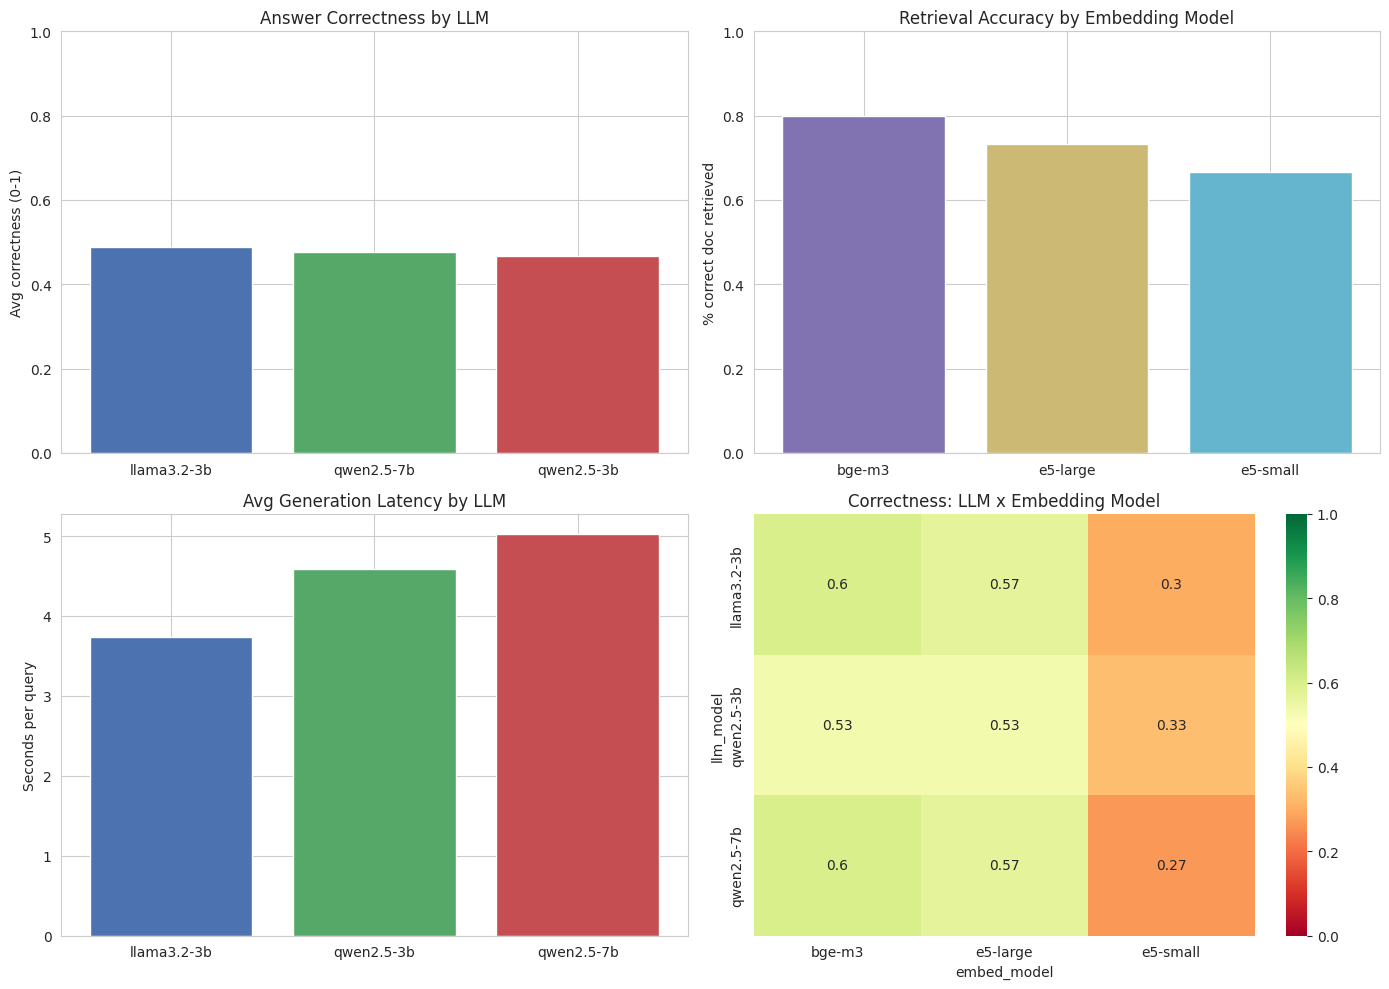

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Correctness by LLM
llm_correctness = df.groupby("llm_model")["correctness_score"].mean().sort_values(ascending=False)
axes[0,0].bar(llm_correctness.index, llm_correctness.values, color=["#4C72B0","#55A868","#C44E52"])
axes[0,0].set_title("Answer Correctness by LLM")
axes[0,0].set_ylabel("Avg correctness (0-1)")
axes[0,0].set_ylim(0, 1)

# 2. Retrieval accuracy by embedding model
embed_acc = df.groupby("embed_model")["retrieved_correct_doc"].mean().sort_values(ascending=False)
axes[0,1].bar(embed_acc.index, embed_acc.values, color=["#8172B2","#CCB974","#64B5CD"])
axes[0,1].set_title("Retrieval Accuracy by Embedding Model")
axes[0,1].set_ylabel("% correct doc retrieved")
axes[0,1].set_ylim(0, 1)

# 3. Latency by LLM
llm_latency = df.groupby("llm_model")["latency_sec"].mean().sort_values()
axes[1,0].bar(llm_latency.index, llm_latency.values, color=["#4C72B0","#55A868","#C44E52"])
axes[1,0].set_title("Avg Generation Latency by LLM")
axes[1,0].set_ylabel("Seconds per query")

# 4. Heatmap: correctness across LLM x embedding model combos
pivot = df.pivot_table(index="llm_model", columns="embed_model", values="correctness_score", aggfunc="mean")
sns.heatmap(pivot, annot=True, cmap="RdYlGn", vmin=0, vmax=1, ax=axes[1,1])
axes[1,1].set_title("Correctness: LLM x Embedding Model")

plt.tight_layout()
plt.savefig("/kaggle/working/benchmark_results.png", dpi=150)
plt.show()

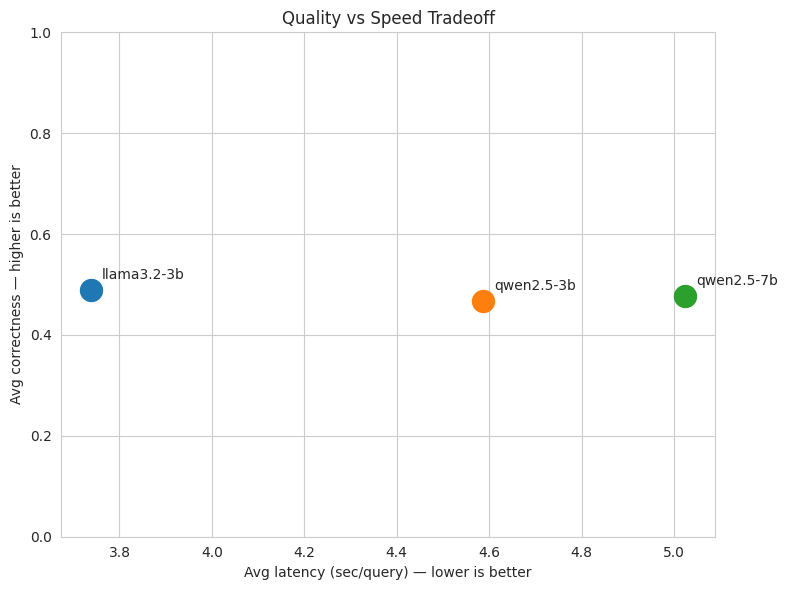

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
model_summary = df.groupby("llm_model").agg(
    correctness=("correctness_score", "mean"),
    latency=("latency_sec", "mean"),
).reset_index()

for _, row in model_summary.iterrows():
    ax.scatter(row["latency"], row["correctness"], s=250)
    ax.annotate(row["llm_model"], (row["latency"], row["correctness"]), xytext=(8, 8), textcoords="offset points")

ax.set_xlabel("Avg latency (sec/query) — lower is better")
ax.set_ylabel("Avg correctness — higher is better")
ax.set_title("Quality vs Speed Tradeoff")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("/kaggle/working/quality_vs_speed.png", dpi=150)
plt.show()

In [22]:
failures = df[df["correctness_score"] == 0].sample(min(5, len(df[df["correctness_score"]==0])), random_state=1)
for _, row in failures.iterrows():
    print(f"Q: {row['question']}")
    print(f"Expected: {row['expected']}")
    print(f"Got: {row['got'][:300]}")
    print(f"Retrieved correct doc: {row['retrieved_correct_doc']}")
    print("---")

Q: What is TAIBI MOHAMMED's total score (Test + TP) in Note web M1IA?
Expected: 19.75
Got: The information about TAIBI MOHAMMED is not present in the provided context. Therefore, I cannot provide an answer based on the given sources.
Retrieved correct doc: True
---
Q: What is TAIBI MOHAMMED's total score (Test + TP) in Note web M1IA?
Expected: 19.75
Got: I couldn't find any information about TAIBI MOHAMMED in the provided context. The context only lists the names and some other information, but it does not include any scores or data related to TAIBI MOHAMMED. 

Source: L2.docx
Retrieved correct doc: False
---
Q: In the Cc_Logique_Mathematique exam, who is the professor and what academic year is it from?
Expected: Mr. Hadjila Fethallah, année universitaire 2015-2016
Got: The information provided does not include details about a Cc_Logique_Mathematique exam, nor does it contain the name of the professor or the specific academic year for that exam. The sources given are for Algorithmique 

In [23]:
def categorize(source_doc):
    ext = source_doc.lower().rsplit(".", 1)[-1]
    if ext in ["xls", "xlsx", "ods"]:
        return "tabular_lookup"
    return "conceptual_text"

df["category"] = df["source_doc"].apply(categorize)
print(df["category"].value_counts())

category
conceptual_text    99
tabular_lookup     36
Name: count, dtype: int64


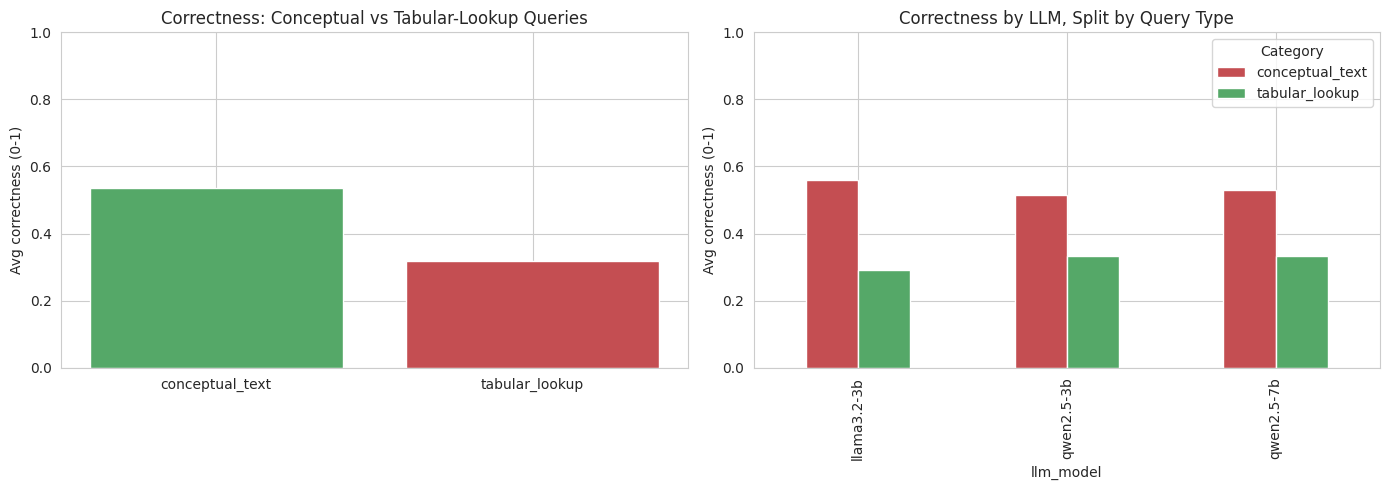

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correctness by category (overall pipeline limitation, not per-model)
cat_scores = df.groupby("category")["correctness_score"].mean()
axes[0].bar(cat_scores.index, cat_scores.values, color=["#55A868", "#C44E52"])
axes[0].set_title("Correctness: Conceptual vs Tabular-Lookup Queries")
axes[0].set_ylabel("Avg correctness (0-1)")
axes[0].set_ylim(0, 1)

# Correctness by LLM, split by category
pivot_cat = df.pivot_table(index="llm_model", columns="category", values="correctness_score", aggfunc="mean")
pivot_cat.plot(kind="bar", ax=axes[1], color=["#C44E52", "#55A868"])
axes[1].set_title("Correctness by LLM, Split by Query Type")
axes[1].set_ylabel("Avg correctness (0-1)")
axes[1].set_ylim(0, 1)
axes[1].legend(title="Category")

plt.tight_layout()
plt.savefig("/kaggle/working/category_breakdown.png", dpi=150)
plt.show()

In [25]:
summary = df.groupby(["llm_model", "embed_model"]).agg(
    correctness=("correctness_score", "mean"),
    retrieval_acc=("retrieved_correct_doc", "mean"),
    latency=("latency_sec", "mean"),
).round(3).sort_values("correctness", ascending=False)

print(summary)
summary.to_csv("/kaggle/working/final_summary.csv")

                         correctness  retrieval_acc  latency
llm_model   embed_model                                     
llama3.2-3b bge-m3             0.600          0.800    4.141
qwen2.5-7b  bge-m3             0.600          0.800    5.104
llama3.2-3b e5-large           0.567          0.733    3.910
qwen2.5-7b  e5-large           0.567          0.733    5.604
qwen2.5-3b  bge-m3             0.533          0.800    4.863
            e5-large           0.533          0.733    4.513
            e5-small           0.333          0.667    4.384
llama3.2-3b e5-small           0.300          0.667    3.164
qwen2.5-7b  e5-small           0.267          0.667    4.367


In [27]:

print(cat_scores)
print(pivot_cat)

category
conceptual_text    0.535354
tabular_lookup     0.319444
Name: correctness_score, dtype: float64
category     conceptual_text  tabular_lookup
llm_model                                   
llama3.2-3b         0.560606        0.291667
qwen2.5-3b          0.515152        0.333333
qwen2.5-7b          0.530303        0.333333


## Findings

**Retrieval quality is the primary bottleneck, not the choice of LLM.** 
Correctness was 0.67 when the correct document was retrieved vs 0.01 when it 
wasn't — the generation model mattered far less than whether retrieval surfaced 
the right content in the first place.

**Dense embedding search handles conceptual/textual content reasonably well but 
struggles on exact tabular lookups.** Splitting results by query type:

- Conceptual/textual queries (math PDFs, slides, definitions): **53.5% correctness**
- Tabular exact-lookup queries (e.g. "what is student X's grade"): **31.9% correctness**

This gap held consistently across all three LLMs tested (Llama-3.2-3B: 56.1% vs 
29.2%, Qwen2.5-3B: 51.5% vs 33.3%, Qwen2.5-7B: 53.0% vs 33.3%) — confirming this 
is a retrieval-layer limitation, not something a bigger or different generation 
model fixes. Dense embeddings cluster by semantic meaning, not exact identity, so 
a name buried among hundreds of similar table rows doesn't stand out in vector 
space regardless of chunk size or embedding model choice.

**Best performing configuration: Llama-3.2-3B + bge-m3** (0.600 correctness, 0.800 
retrieval accuracy, 4.1s avg latency) — tied for the highest correctness score 
with Qwen2.5-7B + bge-m3, but at ~20% lower latency and less than half the model 
size. This is a notable finding on its own: once retrieval surfaces the right 
context, a smaller 3B model answers just as accurately as a 7B model — model size 
stopped being the limiting factor once retrieval quality was controlled for.

**bge-m3 was the strongest embedding model across every LLM tested** (0.800 
retrieval accuracy vs 0.667–0.733 for e5-small/e5-large), making it the 
recommended default embedding model for DocMind.

**Recommended default configuration for DocMind:** Llama-3.2-3B-Instruct + 
bge-m3 embeddings, for text-heavy/conceptual document types.

## Future Work: Hybrid Router Architecture

Production RAG systems handle this exact limitation with query routing rather 
than forcing all queries through a single retrieval path:

- A lightweight classifier (heuristic or small LLM) routes each incoming query 
  to either vector search (conceptual queries) or text-to-SQL (tabular 
  exact-lookup queries)
- Tabular files would be ingested as real Postgres tables (using pgvector, 
  already part of the PIOS stack) rather than embedded row-chunks, enabling 
  exact SQL filters, aggregations, and joins
- Guardrails needed: read-only DB role, query timeouts, a SQL 
  validate-execute-retry loop, and router-accuracy validation against a 
  held-out query set — this last point matters especially for a locally-run 
  router model, since quantization can silently degrade classification accuracy 
  (a failure mode previously observed with xLAM-7b tool selection on PIOS)

This benchmark's core finding — that dense retrieval alone accounts for roughly 
a 20-point correctness gap on exact tabular queries versus conceptual queries — 
is the direct empirical justification for adding this routing layer in DocMind v2.